# NB0 — Data Loading & Quality Dashboard

**Purpose**: Load, clean, validate, and explore the PerCoTate dataset.  
This notebook is purely descriptive — no hypothesis testing.  
All subsequent notebooks import from `helpers.py` which implements the same loading/cleaning pipeline.

---

In [1]:
# ── Imports & Setup ──
import sys, os, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)

# Ensure helpers.py is importable
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from helpers import (
    load_and_clean, derive_variables, get_participant_summary,
    get_completers, get_dropouts, flag_speeders,
    setup_plotting, COLORS, CONDITION_PALETTE, CSV_PATH,
    SYMPTOM_MAP, KL_SEVERITY_MAP
)

plt, sns = setup_plotting()
print(f'CSV path: {CSV_PATH}')

CSV path: /Users/baltaymarci/Documents/Feel Good AI/Analysis/Original Analysis/../data/participants.csv


## 1. Load & Clean

In [2]:
df_raw = load_and_clean()
df = derive_variables(df_raw)

print(f'Total rows:           {len(df):,}')
print(f'Columns:              {df.shape[1]}')
print(f'Unique participants:  {df["participant_id"].nunique()}')
print(f'Completers:           {df[df["is_completer"]]["participant_id"].nunique()}')
print(f'Dropouts:             {df[~df["is_completer"]]["participant_id"].nunique()}')

df.head(3)

Total rows:           5,950
Columns:              79
Unique participants:  68
Completers:           51
Dropouts:             17


,age,ai_confidence,ai_prediction,ai_shown,big5_agreeableness,big5_conscientiousness,big5_extraversion,big5_neuroticism,big5_open_mindedness,big5_timestamp,...,agreed_with_ai,over_reliance,skepticism,confidence_shift,trial_block,phase,symptom1_en,symptom2_en,kl_severity,has_psychometrics
0,17,0.3771,0,False,3.17,3.67,2.92,2.83,3.67,1.770286e+12,...,NaN,NaN,NaN,NaN,1-10,Phase 1,NaN,NaN,healthy,True
1,17,0.6423,0,False,3.17,3.67,2.92,2.83,3.67,1.770286e+12,...,NaN,NaN,NaN,NaN,1-10,Phase 1,NaN,NaN,healthy,True
2,17,0.8646,0,False,3.17,3.67,2.92,2.83,3.67,1.770286e+12,...,NaN,NaN,NaN,NaN,1-10,Phase 1,NaN,NaN,healthy,True


## 2. Data Types & Missing Values

In [3]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print()
display(missing_df)

Columns with missing values: 43



,missing_count,missing_pct
final_confidence,2900,48.7
decision_changed,2900,48.7
phase1_video_watched,2900,48.7
reverted_decision,2900,48.7
symptom1,2900,48.7
symptom2,2900,48.7
pre_ai_correct,2900,48.7
ai_correct,2900,48.7
changed_to_correct,2900,48.7
final_decision,2900,48.7


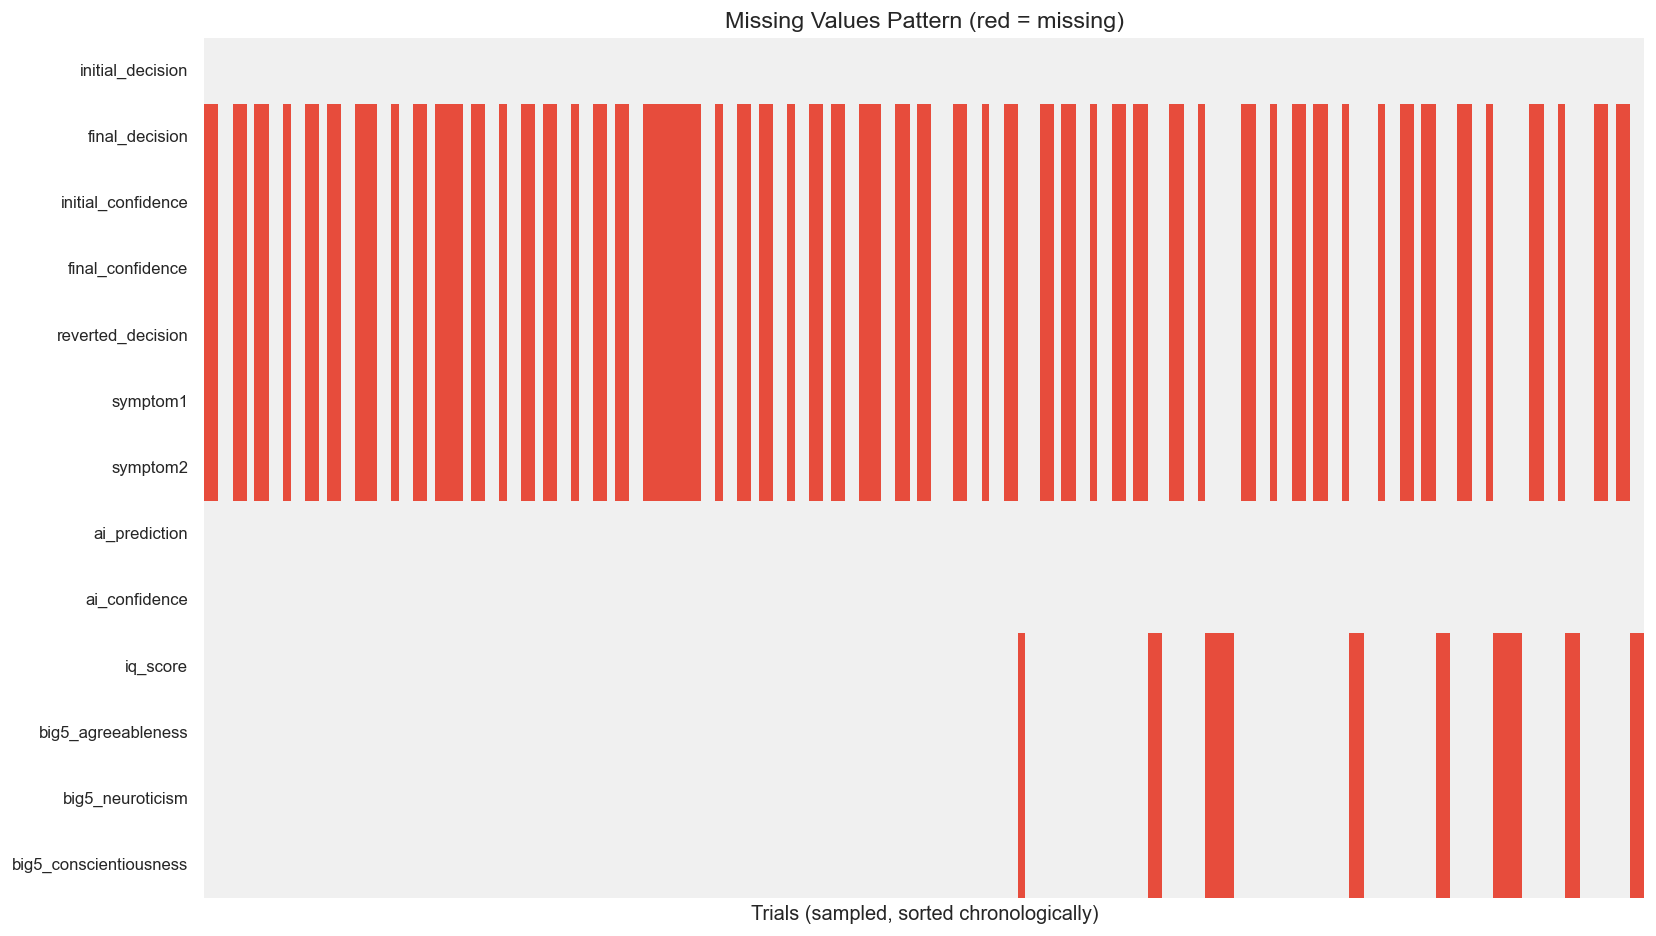

In [4]:
# Missing values heatmap — focus on key variables, grouped by participant
key_cols = [
    'initial_decision', 'final_decision', 'initial_confidence', 'final_confidence',
    'reverted_decision', 'symptom1', 'symptom2', 'ai_prediction', 'ai_confidence',
    'iq_score', 'big5_agreeableness', 'big5_neuroticism', 'big5_conscientiousness'
]

fig, ax = plt.subplots(figsize=(14, 8))
missing_matrix = df[key_cols].isnull().astype(int)
# Sample evenly for visibility
sample_idx = np.linspace(0, len(df)-1, min(200, len(df)), dtype=int)
sns.heatmap(
    missing_matrix.iloc[sample_idx].T,
    cbar=False, cmap=['#f0f0f0', '#e74c3c'],
    yticklabels=True, xticklabels=False, ax=ax
)
ax.set_title('Missing Values Pattern (red = missing)', fontsize=14)
ax.set_xlabel('Trials (sampled, sorted chronologically)')
plt.tight_layout()
plt.show()

## 3. Participant Demographics

In [5]:
ps = get_participant_summary(df)

# Demographics table
demo_vars = ['age', 'gender', 'school', 'residence', 'treatment_group', 'is_completer', 'n_trials']
print('=== Participant Demographics ===')
print(f'N = {len(ps)}')
print(f'  Completers: {ps["is_completer"].sum()} | Dropouts: {(~ps["is_completer"]).sum()}')
print(f'  Gender: {ps["gender"].value_counts().to_dict()}')
print(f'  Age: mean={ps["age"].mean():.1f}, SD={ps["age"].std():.1f}, range=[{ps["age"].min()}, {ps["age"].max()}]')
print(f'  School: {ps["school"].value_counts().to_dict()}')
print(f'  Residence: {ps["residence"].value_counts().to_dict()}')
print(f'  Treatment group: {ps["treatment_group"].value_counts().to_dict()}')

=== Participant Demographics ===
N = 68
  Completers: 51 | Dropouts: 17
  Gender: {'female': 35, 'male': 33}
  Age: mean=16.3, SD=0.7, range=[15, 18]
  School: {'secondary': 61, 'primary': 7}
  Residence: {'budapest': 48, 'city': 13, 'village': 7}
  Treatment group: {'0': 34, '1': 34}


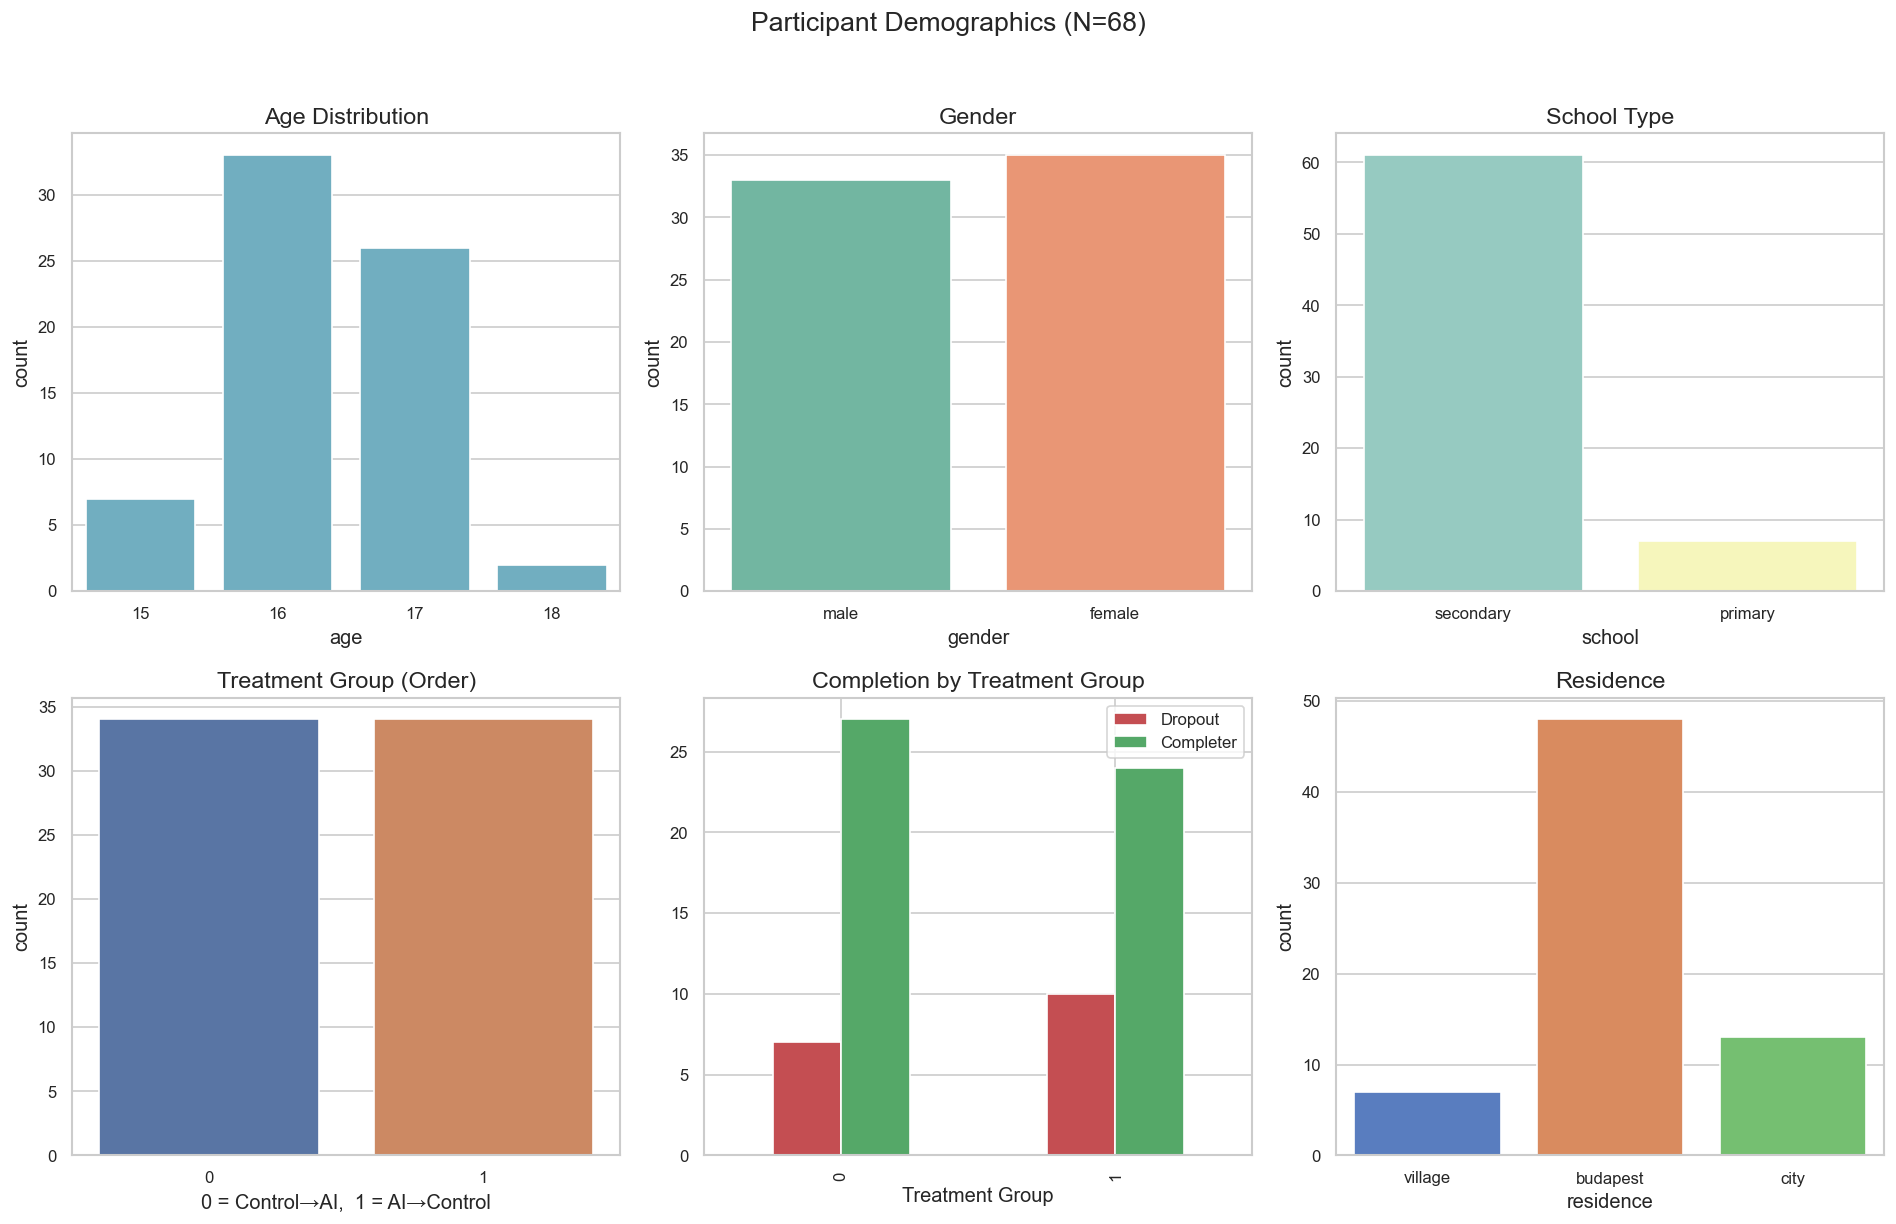

In [6]:
# Demographics visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age
sns.countplot(data=ps, x='age', ax=axes[0, 0], color=COLORS['neutral'])
axes[0, 0].set_title('Age Distribution')

# Gender
sns.countplot(data=ps, x='gender', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Gender')

# School type
sns.countplot(data=ps, x='school', ax=axes[0, 2], palette='Set3')
axes[0, 2].set_title('School Type')

# Treatment group
sns.countplot(data=ps, x='treatment_group', ax=axes[1, 0], palette=[COLORS['control'], COLORS['ai']])
axes[1, 0].set_title('Treatment Group (Order)')
axes[1, 0].set_xlabel('0 = Control→AI,  1 = AI→Control')

# Completion status by treatment group
completion = ps.groupby(['treatment_group', 'is_completer']).size().unstack(fill_value=0)
completion.plot(kind='bar', ax=axes[1, 1], color=[COLORS['incorrect'], COLORS['correct']])
axes[1, 1].set_title('Completion by Treatment Group')
axes[1, 1].legend(['Dropout', 'Completer'])
axes[1, 1].set_xlabel('Treatment Group')

# Residence
sns.countplot(data=ps, x='residence', ax=axes[1, 2], palette='muted')
axes[1, 2].set_title('Residence')

plt.suptitle('Participant Demographics (N=68)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Ground Truth & Class Balance

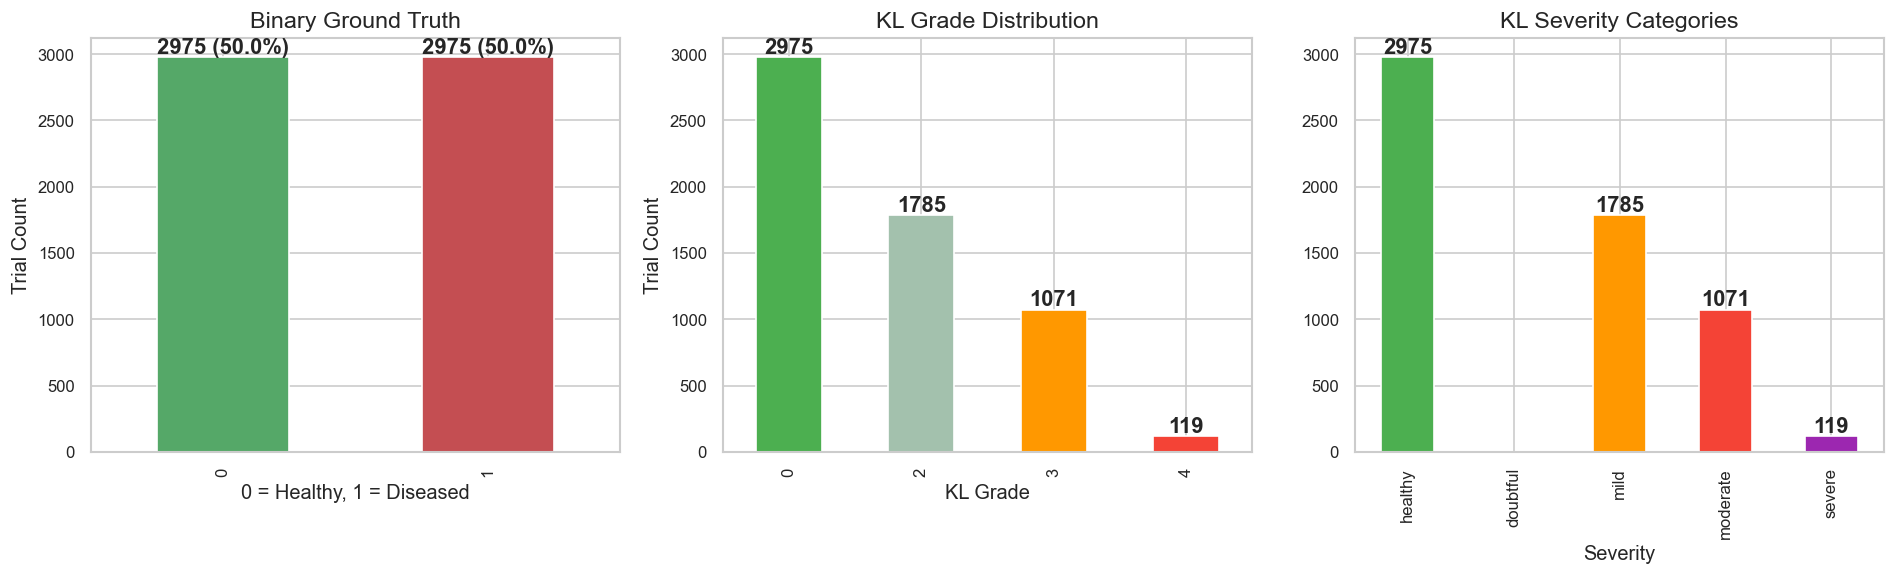


Binary mapping: KL0→Healthy(0), KL1→Doubtful(1), KL2-4→Diseased(1)
Class balance: 50.0% Healthy vs 50.0% Diseased


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Binary ground truth
gt_binary = df['ground_truth_binary'].value_counts().sort_index()
gt_binary.plot(kind='bar', ax=axes[0], color=[COLORS['correct'], COLORS['incorrect']])
axes[0].set_title('Binary Ground Truth')
axes[0].set_xlabel('0 = Healthy, 1 = Diseased')
axes[0].set_ylabel('Trial Count')
for i, v in enumerate(gt_binary):
    axes[0].text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# KL Grade distribution
kl_counts = df['ground_truth_raw'].value_counts().sort_index()
# Added color for KL1 (doubtful)
kl_counts.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#A3C1AD', '#FF9800', '#F44336', '#9C27B0'])
axes[1].set_title('KL Grade Distribution')
axes[1].set_xlabel('KL Grade')
axes[1].set_ylabel('Trial Count')
for i, v in enumerate(kl_counts):
    axes[1].text(i, v + 30, f'{v}', ha='center', fontweight='bold')

# KL Severity labels
sev_order = ['healthy', 'doubtful', 'mild', 'moderate', 'severe']
sev_counts = df['kl_severity'].value_counts().reindex(sev_order)
# Added color for KL1 (doubtful)
sev_counts.plot(kind='bar', ax=axes[2], color=['#4CAF50', '#A3C1AD', '#FF9800', '#F44336', '#9C27B0'])
axes[2].set_title('KL Severity Categories')
axes[2].set_xlabel('Severity')
for i, v in enumerate(sev_counts):
    # Ignore NaN values visually if a bar is empty conceptually
    if pd.notna(v):
        axes[2].text(i, v + 30, f'{int(v)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nBinary mapping: KL0→Healthy(0), KL1→Doubtful(1), KL2-4→Diseased(1)')
print(f'Class balance: {gt_binary[0]/len(df)*100:.1f}% Healthy vs {gt_binary[1]/len(df)*100:.1f}% Diseased')


## 5. AI Model Audit

AI Overall Accuracy: 70.0% (n=3050 trials)


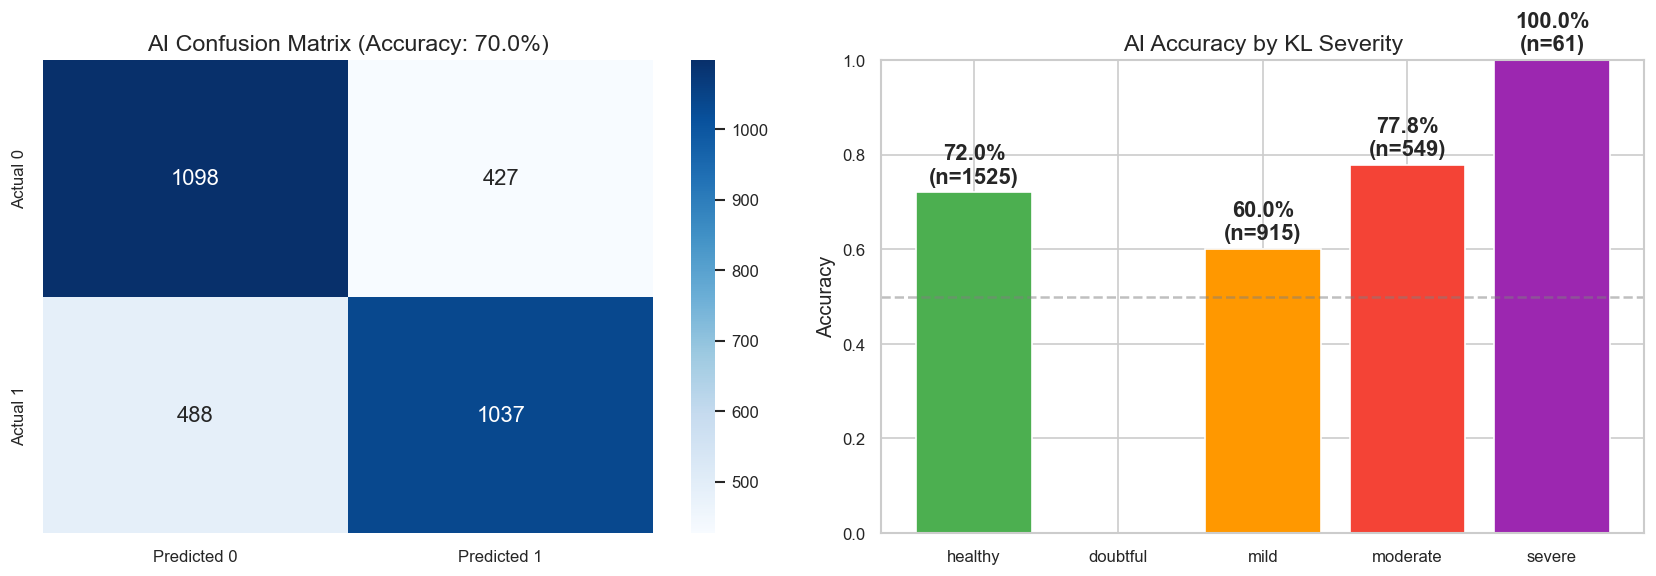


AI Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.69      0.72      0.71      1525
Diseased (1)       0.71      0.68      0.69      1525

    accuracy                           0.70      3050
   macro avg       0.70      0.70      0.70      3050
weighted avg       0.70      0.70      0.70      3050



In [8]:
ai_trials = df[df['ai_shown'] == True].copy()

# Overall AI accuracy
ai_acc = ai_trials['ai_correct'].mean()
print(f'AI Overall Accuracy: {ai_acc:.1%} (n={len(ai_trials)} trials)')

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(ai_trials['ground_truth_binary'], ai_trials['ai_prediction'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title(f'AI Confusion Matrix (Accuracy: {ai_acc:.1%})')

# AI accuracy by KL severity
kl_order = ['healthy', 'doubtful', 'mild', 'moderate', 'severe']
ai_kl = ai_trials.groupby('kl_severity')['ai_correct'].agg(['mean', 'count'])
ai_kl = ai_kl.reindex(kl_order)
bars = axes[1].bar(range(len(ai_kl)), ai_kl['mean'], 
                   color=['#4CAF50', '#A3C1AD', '#FF9800', '#F44336', '#9C27B0'])
axes[1].set_xticks(range(len(ai_kl)))
axes[1].set_xticklabels(kl_order)
axes[1].set_ylim(0, 1)
axes[1].set_title('AI Accuracy by KL Severity')
axes[1].set_ylabel('Accuracy')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
for bar, (_, row) in zip(bars, ai_kl.iterrows()):
    if not np.isnan(row['count']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{row['mean']:.1%}\n(n={int(row['count'])})", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nAI Classification Report:')
print(classification_report(ai_trials['ground_truth_binary'], ai_trials['ai_prediction'],
                           target_names=['Healthy (0)', 'Diseased (1)']))


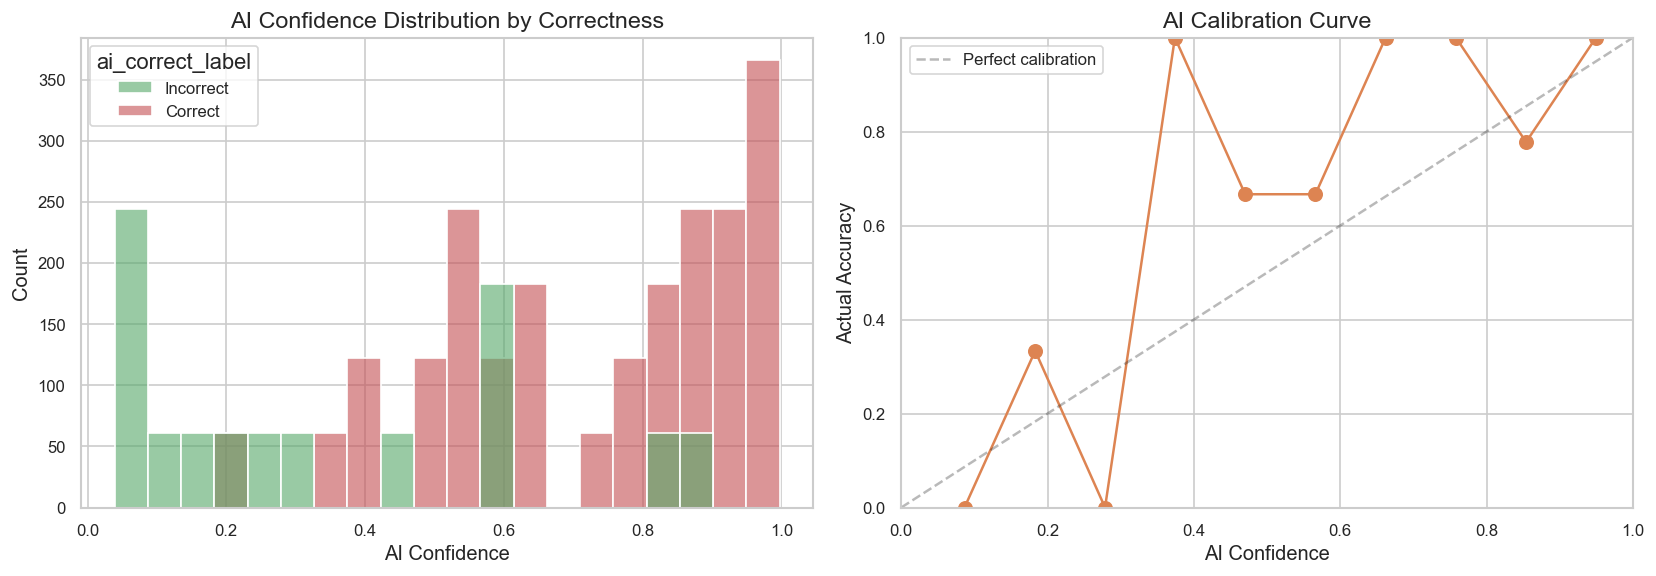

In [9]:
# AI confidence distribution by correctness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ai_trials['ai_correct_label'] = ai_trials['ai_correct'].map({1.0: 'Correct', 0.0: 'Incorrect'})
sns.histplot(data=ai_trials, x='ai_confidence', hue='ai_correct_label', 
             bins=20, ax=axes[0], palette=[COLORS['correct'], COLORS['incorrect']], alpha=0.6)
axes[0].set_title('AI Confidence Distribution by Correctness')
axes[0].set_xlabel('AI Confidence')

# AI confidence vs actual accuracy (calibration)
ai_trials['ai_conf_bin'] = pd.cut(ai_trials['ai_confidence'], bins=10)
cal = ai_trials.groupby('ai_conf_bin')['ai_correct'].agg(['mean', 'count'])
ax = axes[1]
valid = cal[cal['count'] >= 5]
midpoints = [interval.mid for interval in valid.index]
ax.plot(midpoints, valid['mean'], 'o-', color=COLORS['ai'], markersize=8)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('AI Calibration Curve')
ax.set_xlabel('AI Confidence')
ax.set_ylabel('Actual Accuracy')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Speeder Detection

Exploring multiple methods to identify participants who are not engaging genuinely with the task.

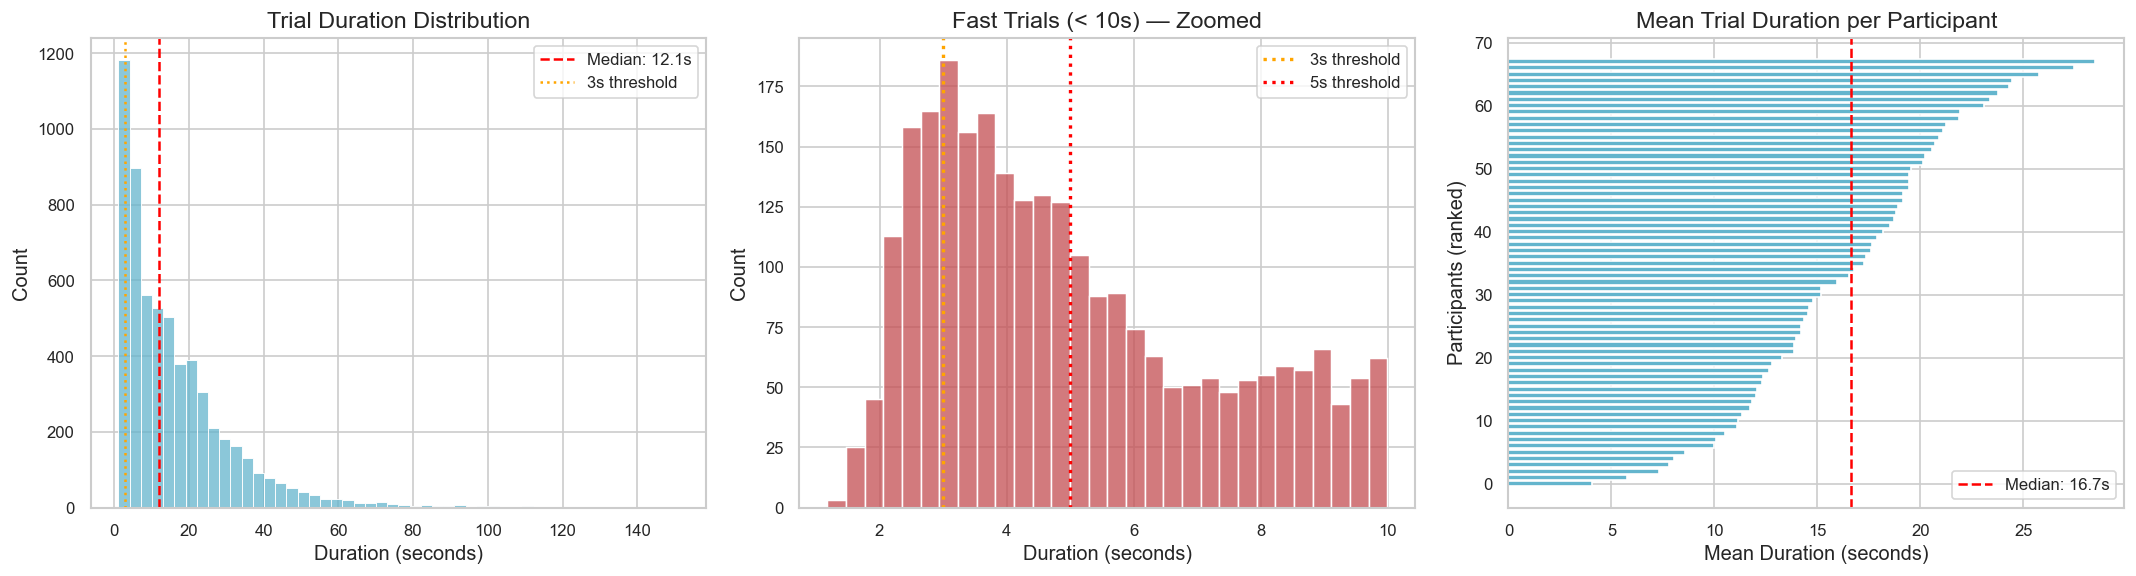

Duration stats: min=1.2s, median=12.1s, mean=16.4s, max=151.0s
Trials < 3s: 538 (9.0%)
Trials < 5s: 1537 (25.8%)


In [10]:
# Trial duration distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall distribution
sns.histplot(df['trial_duration'], bins=50, ax=axes[0], color=COLORS['neutral'])
axes[0].axvline(x=df['trial_duration'].median(), color='red', linestyle='--', label=f'Median: {df["trial_duration"].median():.1f}s')
axes[0].axvline(x=3, color='orange', linestyle=':', label='3s threshold')
axes[0].set_title('Trial Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].legend()

# Zoomed in on fast trials
fast = df[df['trial_duration'] < 10]
sns.histplot(fast['trial_duration'], bins=30, ax=axes[1], color=COLORS['incorrect'])
axes[1].axvline(x=3, color='orange', linestyle=':', linewidth=2, label='3s threshold')
axes[1].axvline(x=5, color='red', linestyle=':', linewidth=2, label='5s threshold')
axes[1].set_title('Fast Trials (< 10s) — Zoomed')
axes[1].set_xlabel('Duration (seconds)')
axes[1].legend()

# Per-participant mean duration
p_duration = df.groupby('participant_id')['trial_duration'].mean().sort_values()
axes[2].barh(range(len(p_duration)), p_duration.values, color=COLORS['neutral'], height=0.8)
axes[2].axvline(x=p_duration.median(), color='red', linestyle='--', label=f'Median: {p_duration.median():.1f}s')
axes[2].set_title('Mean Trial Duration per Participant')
axes[2].set_xlabel('Mean Duration (seconds)')
axes[2].set_ylabel('Participants (ranked)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Duration stats: min={df["trial_duration"].min():.1f}s, '
      f'median={df["trial_duration"].median():.1f}s, '
      f'mean={df["trial_duration"].mean():.1f}s, '
      f'max={df["trial_duration"].max():.1f}s')
print(f'Trials < 3s: {(df["trial_duration"] < 3).sum()} ({(df["trial_duration"] < 3).mean()*100:.1f}%)')
print(f'Trials < 5s: {(df["trial_duration"] < 5).sum()} ({(df["trial_duration"] < 5).mean()*100:.1f}%)')

In [11]:
# Compare three speeder detection methods
methods = {
    'Fixed < 3s': ('fixed', {'threshold': 3.0}),
    'Fixed < 5s': ('fixed', {'threshold': 5.0}),
    'Z-score < -2': ('zscore', {'z_threshold': -2.0}),
    '5th percentile': ('percentile', {'percentile': 5.0}),
}

results = []
for name, (method, kwargs) in methods.items():
    df_flagged = flag_speeders(df, method=method, **kwargs)
    n_trials = df_flagged['is_speeder_trial'].sum()
    n_participants = df_flagged.groupby('participant_id')['is_speeder_participant'].first().sum()
    
    # Accuracy of flagged vs non-flagged trials
    acc_flagged = df_flagged[df_flagged['is_speeder_trial']]['user_correct'].mean()
    acc_normal = df_flagged[~df_flagged['is_speeder_trial']]['user_correct'].mean()
    
    results.append({
        'Method': name,
        'Flagged Trials': n_trials,
        'Flagged %': f'{n_trials/len(df)*100:.1f}%',
        'Flagged Participants': int(n_participants),
        'Acc (flagged)': f'{acc_flagged:.1%}' if not np.isnan(acc_flagged) else 'N/A',
        'Acc (normal)': f'{acc_normal:.1%}',
    })

results_df = pd.DataFrame(results)
display(results_df)

print('\n→ This table helps decide which speeder threshold to use.')
print('  A good threshold flags trials with notably lower accuracy.')

,Method,Flagged Trials,Flagged %,Flagged Participants,Acc (flagged),Acc (normal)
0,Fixed < 3s,538,9.0%,0,68.2%,62.4%
1,Fixed < 5s,1537,25.8%,2,65.1%,62.2%
2,Z-score < -2,0,0.0%,0,N/A,62.9%
3,5th percentile,297,5.0%,0,66.0%,62.7%



→ This table helps decide which speeder threshold to use.
  A good threshold flags trials with notably lower accuracy.


## 7. Dropout Characterization

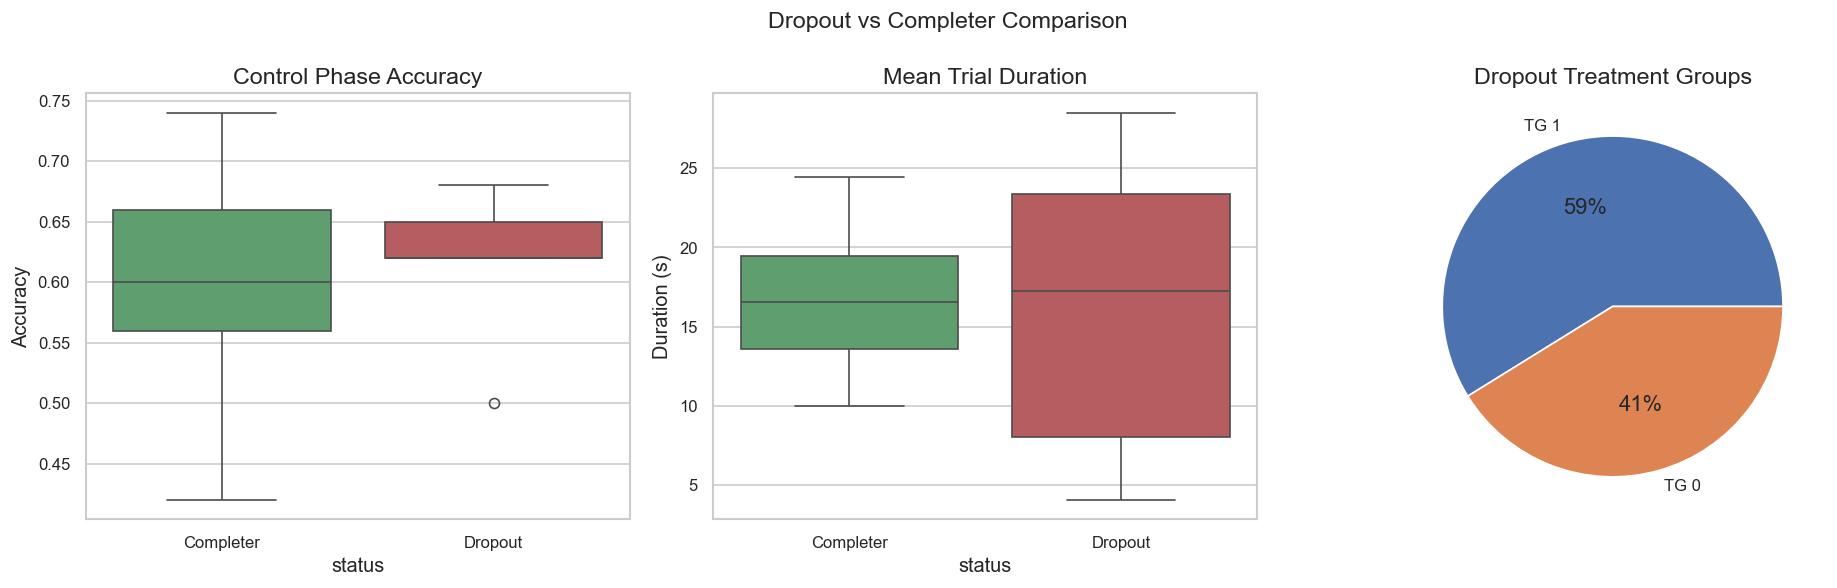

Dropouts: 17 participants
  TG=0 dropouts: 7 (had Control only → have psychometrics)
  TG=1 dropouts: 10 (had AI only → NO psychometrics)


In [12]:
# Compare dropouts vs completers on demographics & performance
ps['status'] = ps['is_completer'].map({True: 'Completer', False: 'Dropout'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Control accuracy comparison (all participants have a control phase)
sns.boxplot(data=ps[ps['control_accuracy'].notna()], x='status', y='control_accuracy',
            ax=axes[0], palette=[COLORS['correct'], COLORS['incorrect']])
axes[0].set_title('Control Phase Accuracy')
axes[0].set_ylabel('Accuracy')

# Mean trial duration
sns.boxplot(data=ps, x='status', y='overall_mean_duration',
            ax=axes[1], palette=[COLORS['correct'], COLORS['incorrect']])
axes[1].set_title('Mean Trial Duration')
axes[1].set_ylabel('Duration (s)')

# Treatment group distribution
dropout_tg = ps[ps['status'] == 'Dropout']['treatment_group'].value_counts()
axes[2].pie(dropout_tg, labels=[f'TG {k}' for k in dropout_tg.index], 
           autopct='%1.0f%%', colors=[COLORS['control'], COLORS['ai']])
axes[2].set_title('Dropout Treatment Groups')

plt.suptitle('Dropout vs Completer Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Dropouts: {(~ps["is_completer"]).sum()} participants')
print(f'  TG=0 dropouts: {len(ps[(~ps["is_completer"]) & (ps["treatment_group"]=="0")])} (had Control only → have psychometrics)')
print(f'  TG=1 dropouts: {len(ps[(~ps["is_completer"]) & (ps["treatment_group"]=="1")])} (had AI only → NO psychometrics)')

## 8. Quick Overview — Key Variable Distributions

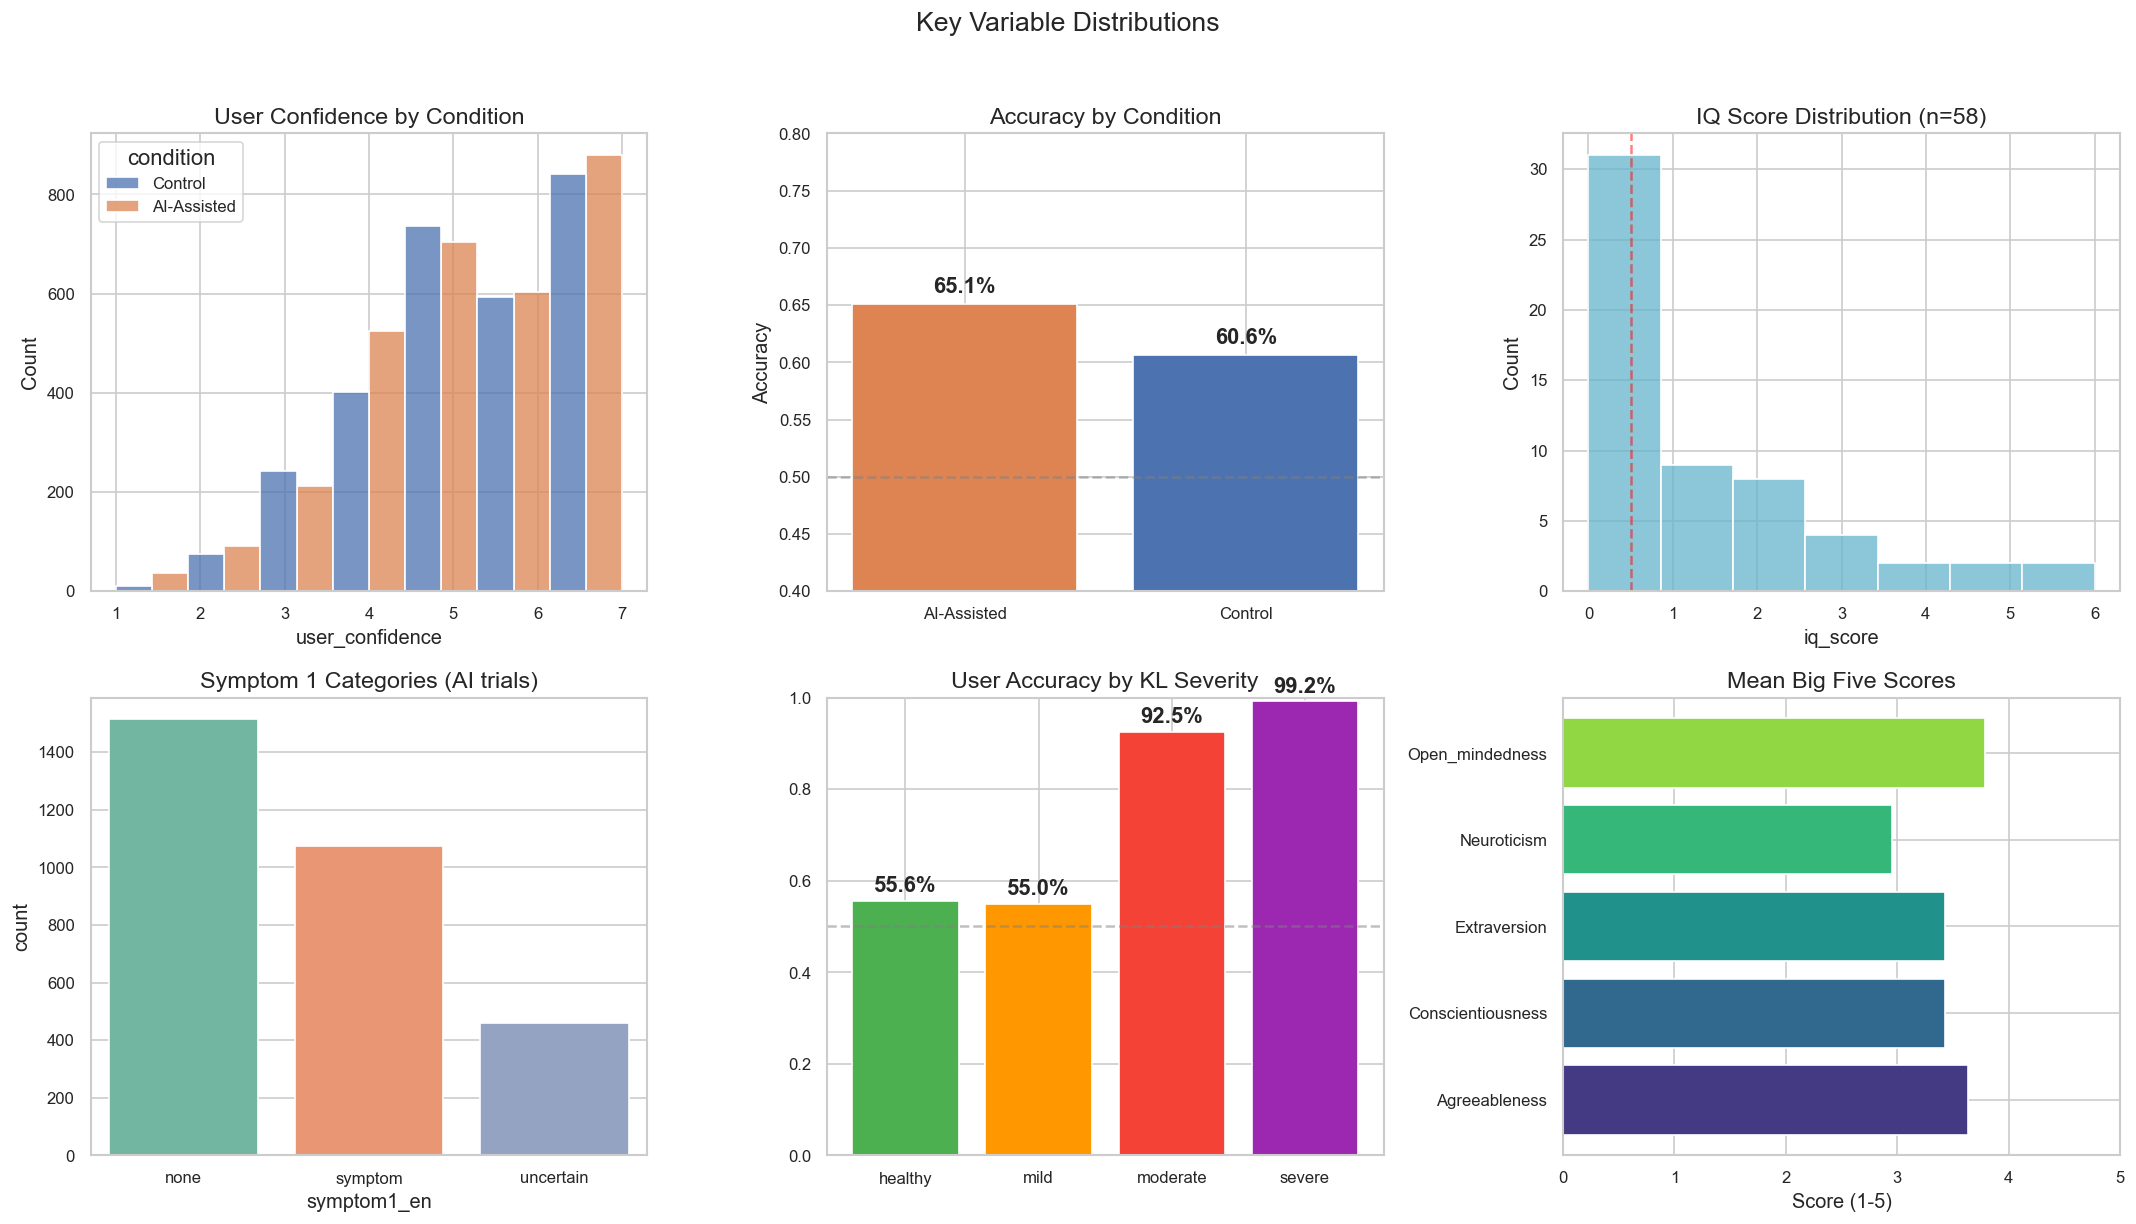

In [13]:
# Key variable distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# User confidence (unified)
sns.histplot(data=df, x='user_confidence', hue='condition', bins=7, 
             ax=axes[0, 0], palette=CONDITION_PALETTE, multiple='dodge')
axes[0, 0].set_title('User Confidence by Condition')

# User accuracy by condition
acc_by_cond = df.groupby('condition')['user_correct'].mean()
bars = axes[0, 1].bar(acc_by_cond.index, acc_by_cond.values, 
                      color=[COLORS['ai'], COLORS['control']])
axes[0, 1].set_ylim(0.4, 0.8)
axes[0, 1].set_title('Accuracy by Condition')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, acc_by_cond.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 0.01, 
                   f'{val:.1%}', ha='center', fontweight='bold')

# IQ distribution
iq_data = ps[ps['iq_score'].notna()]
sns.histplot(data=iq_data, x='iq_score', bins=7, ax=axes[0, 2], color=COLORS['neutral'])
axes[0, 2].set_title(f'IQ Score Distribution (n={len(iq_data)})')
axes[0, 2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

# Symptom categories (AI trials only)
symptom_data = ai_trials[ai_trials['symptom1_en'].notna()]
sns.countplot(data=symptom_data, x='symptom1_en', ax=axes[1, 0], 
              order=['none', 'symptom', 'uncertain'], palette='Set2')
axes[1, 0].set_title('Symptom 1 Categories (AI trials)')

# KL grade accuracy
kl_acc = df.groupby('kl_severity')['user_correct'].mean()
kl_order = ['healthy', 'mild', 'moderate', 'severe']
kl_acc = kl_acc.reindex(kl_order)
bars = axes[1, 1].bar(range(len(kl_acc)), kl_acc.values, 
                      color=['#4CAF50', '#FF9800', '#F44336', '#9C27B0'])
axes[1, 1].set_xticks(range(len(kl_acc)))
axes[1, 1].set_xticklabels(kl_order)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('User Accuracy by KL Severity')
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, kl_acc.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val + 0.02, 
                   f'{val:.1%}', ha='center', fontweight='bold')

# Big 5 overview (radar-like bar chart)
b5_cols = ['big5_agreeableness', 'big5_conscientiousness', 'big5_extraversion', 
           'big5_neuroticism', 'big5_open_mindedness']
b5_means = ps[b5_cols].mean()
b5_labels = [c.replace('big5_', '').capitalize() for c in b5_cols]
axes[1, 2].barh(b5_labels, b5_means.values, color=sns.color_palette('viridis', 5))
axes[1, 2].set_xlim(0, 5)
axes[1, 2].set_title('Mean Big Five Scores')
axes[1, 2].set_xlabel('Score (1-5)')

plt.suptitle('Key Variable Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Crossover Design Verification

Verify the experimental structure: Phase 1 → Phase 2 crossover.

In [14]:
# Verify crossover design
completers_df = get_completers(df)

# For each completer: Phase 1 condition vs Phase 2 condition
crossover_check = completers_df.groupby(['participant_id', 'phase']).agg(
    condition=('condition', 'first'),
    n_trials=('trial_order', 'count'),
    treatment_group=('treatment_group', 'first')
).reset_index()

crossover_pivot = crossover_check.pivot(index='participant_id', columns='phase', values='condition')
print('Crossover Design Verification:')
print(crossover_pivot.value_counts())
print()

# Phase × Condition summary
phase_cond = completers_df.groupby(['phase', 'condition']).size().unstack(fill_value=0)
print('Phase × Condition trial counts (completers only):')
display(phase_cond)

print('\n✓ Confirms: TG=0 → Phase1=Control, Phase2=AI | TG=1 → Phase1=AI, Phase2=Control')

Crossover Design Verification:
Phase 1      Phase 2    
Control      AI-Assisted    27
AI-Assisted  Control        24
Name: count, dtype: int64

Phase × Condition trial counts (completers only):


condition,AI-Assisted,Control
phase,,
Phase 1,1200,1350
Phase 2,1350,1200



✓ Confirms: TG=0 → Phase1=Control, Phase2=AI | TG=1 → Phase1=AI, Phase2=Control


## Findings & Next Steps

**Key Data Quality Observations:**
1. Data is clean — missing values follow expected patterns (control trials lack AI-phase fields)
2. Crossover design verified: 51 completers, 17 dropouts (all Phase 1 only)
3. Class balance is roughly 50/50 (healthy vs diseased)
4. AI accuracy is ~70% as expected
5. 31/58 participants with IQ data scored 0 — critical subgroup to analyze

**Speeder threshold decision**: Review the comparison table above and decide which method to use for subsequent analyses.

**Next**: Proceed to NB1 (Performance & Accuracy) for hypothesis testing.